In [10]:
import os
import sys
import glob
import json
import pickle
import datetime
import numpy as np
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import scipy as sp
from scipy import signal 

sys.path.insert(1, '../utils')

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

from utils import *
from mUtils import *
from plotUtils import *

%matplotlib inline
plt.rcParams.update({'font.size': 11})

In [11]:
SYNCHMEASURES = {
                    'Avalanch': "Avalanche Dynamic \nSynchronization", 
                    'DistCor': "Distance Correlation",
                    'Kuramoto': "Kuramoto Parameter", 
                    'GlobalSync': "Global Synchronization", 
                    'SVD': "SVD-based Synchronization \nMeasure",
                    'PLV': "Phase Locked Value\n" + r"$\gamma-Oscillations (40 - 85 Hz)$"
}

In [12]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

figureroot = "./results/system_01/synchron"
os.makedirs(figureroot, exist_ok=True)

In [13]:
load_dir = "../system_01/results/synchron/"
load_str = datetime.datetime(2024, 4, 12)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, 'Imod*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 5


In [5]:
# iPert = np.array([0.  , 0.15, 0.25, 0.35, 0.5])[::-1]
# sig_steps = 20; k_steps = 10

# for iP in iPert:
#     iI = iP / params['gamma'] + params['i_e2']

#     kVals = []
#     kPaths = []

#     for nf, path in enumerate(file_paths):
#         baseName = os.path.basename(path).split('mV.pkl')[0]
#         I = float(baseName.split('_')[-1])
#         K = float(baseName.split('_')[2])

#         if round(iI, 3) != I:
#             continue

#         kVals.append(K)
#         kPaths.append(path)
    
#     kVals = np.array(kVals)
#     kPaths = np.array(kPaths)

#     kSorted = np.argsort(kVals)
#     kPaths = kPaths[kSorted]
#     kVals = kVals[kSorted]

#     meanSynch = {}
#     stdSynch = {}

#     fileName = f"Imod_{iI-params['i_e2']:.3f}mV.pkl"
#     for nf, path in enumerate(kPaths):
#         print(nf, path)
#         synchValues = pickle.load(open(path, 'rb'))

#         for measure, _ in SYNCHMEASURES.items():
#             if measure not in meanSynch.keys():
#                 meanSynch[measure] = np.zeros((k_steps, sig_steps))
#                 stdSynch[measure] = np.zeros((k_steps, sig_steps))
            
#             dataArr= synchValues[measure]
#             meanArr = np.mean(dataArr, axis=1)
#             stdArr = np.std(dataArr, axis=1)

#             meanSynch[measure][nf, :] = meanArr
#             stdSynch[measure][nf, :] = stdArr
    
#     RESULTS = {
#                 "Mean": meanSynch,
#                 "Std": stdSynch
#     }
#     with open(os.path.join(results_dir, fileName), "wb") as file_:
#         pickle.dump(RESULTS, file_)

In [6]:
# Sorting the files

iVals = []

for path in file_paths:
    baseName = os.path.basename(path).split('mV.pkl')[0]
    I = float(baseName.split('_')[-1])

    iVals.append(I)

iVals = np.array(iVals)
iSort = np.argsort(iVals)

file_paths = np.array(file_paths)
file_paths = file_paths[iSort]
iVals = iVals[iSort]

In [7]:
iPert = iVals

sig_min = 2.5; sig_max = 16.5; sig_steps = 20
eval_sigma = sig_min + np.arange(0, sig_steps) / (sig_steps - 1) * (sig_max - sig_min)

k_min = -1; k_max = 1; k_steps = 10
eval_k = k_min + np.arange(0, k_steps) / k_steps * (k_max - k_min)

In [8]:
def SeriesData(measure, file_paths):
    data_K_mean = np.zeros((3, k_steps))
    data_K_std = np.zeros((3, k_steps))

    data_I_mean = np.zeros((2, 3, len(iPert)))
    data_I_std = np.zeros((2, 3, len(iPert)))

    for nf, path in enumerate(file_paths):
        print(path)
        baseName = os.path.basename(path).split('mV.pkl')[0]
        I = float(baseName.split('_')[-1])

        synchData = pickle.load(open(path, 'rb'))
        synchMean = synchData['Mean']
        synchSTD = synchData['Std']

        dataArray = synchMean[measure]
        dataArray[np.isnan(dataArray)] = 0.0 
        
        stdArray = synchSTD[measure]
        stdArray[np.isnan(stdArray)] = 0.0 
        
        if measure == "Kuramoto":
            dataArray = dataArray / np.max(dataArray)
            stdArray /= np.max(stdArray)
        
        if measure == "DistCor" or measure == "SVD" or measure == "GlobSynch":
            dataArray[dataArray < 0.09] = 0
        
        if I == iPert[-1]:
            data_K_mean[0, :] = dataArray[:, 0]
            data_K_mean[1, :] = dataArray[:, 9]
            data_K_mean[2, :] = dataArray[:, -1]
            data_K_std[0, :] = synchSTD[measure][:, 0]
            data_K_std[1, :] = synchSTD[measure][:, 9]
            data_K_std[2, :] = synchSTD[measure][:, -1]
            
        data_I_mean[0, 0, nf] = dataArray[2, 0]
        data_I_mean[0, 1, nf] = dataArray[2, 9]
        data_I_mean[0, 2, nf] = dataArray[2, -1]
        data_I_std[0, 0, nf] = synchSTD[measure][2, 0]
        data_I_std[0, 1, nf] = synchSTD[measure][2, 9]
        data_I_std[0, 2, nf] = synchSTD[measure][2, -1]

        data_I_mean[1, 0, nf] = dataArray[6, 0]
        data_I_mean[1, 1, nf] = dataArray[6, 9]
        data_I_mean[1, 2, nf] = dataArray[6, -1]
        data_I_std[1, 0, nf] = synchSTD[measure][6, 0]
        data_I_std[1, 1, nf] = synchSTD[measure][6, 9]
        data_I_std[1, 2, nf] = synchSTD[measure][6, -1]
    
    return data_K_mean, data_K_std, data_I_mean, data_I_std

[[0.37679744 0.31510564 0.30359964 0.2497613  0.11042204 0.10647845
  0.16993092 1.99754992 1.99754992 1.99754992 1.99754992 1.99754992
  0.27382691 0.47446667 0.70413897 0.98537566 1.38574622 0.6214843
  0.         0.        ]
 [1.39826203 0.94494938 1.41165271 0.80112502 1.56886679 1.13281067
  1.3118524  1.37525241 1.5766742  1.80904235 1.99754947 0.21545548
  0.50353018 0.89069158 1.85962552 0.         0.         0.
  0.         0.        ]
 [0.26511183 0.24241886 0.28651863 0.27665434 0.40454637 0.21738671
  1.26311653 0.23330051 0.         0.86825344 1.35072525 0.
  0.56495811 0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.22301215 0.38958931 0.52970793 0.5954041  0.55550865
  0.8204889  1.37407306 0.7892284  0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         1.62982456
  0.78790629 0.28347397 0.         0.         0.         

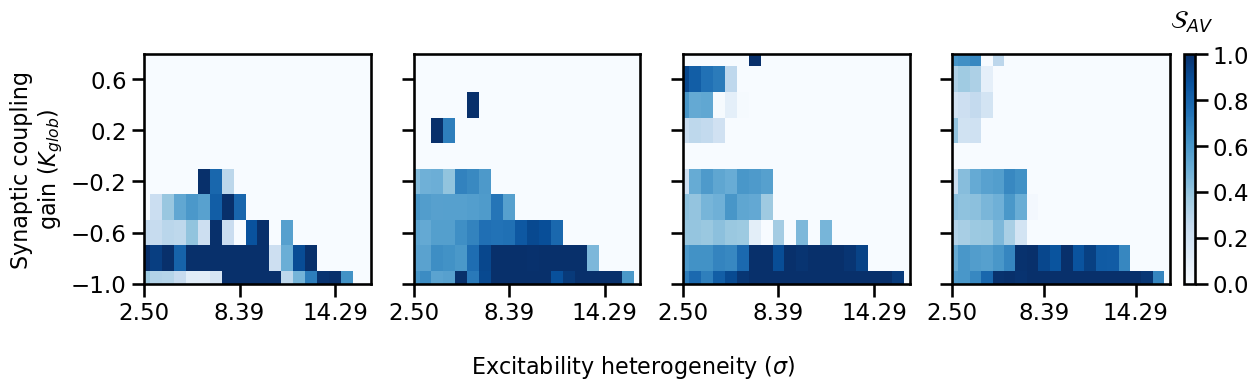

In [9]:
measure = "Avalanch"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 
    print(dataArray)

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{AV}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [10]:
measure = "Avalanch"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-12/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_31.250mV.pkl


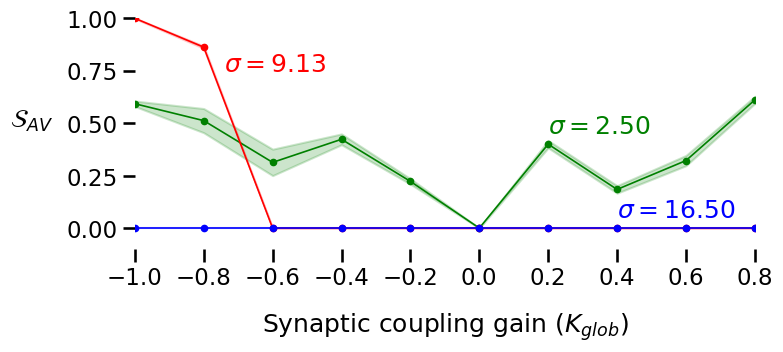

In [11]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{AV}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.2, 0.45, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(-0.74, 0.75, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(0.4, 0.05, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

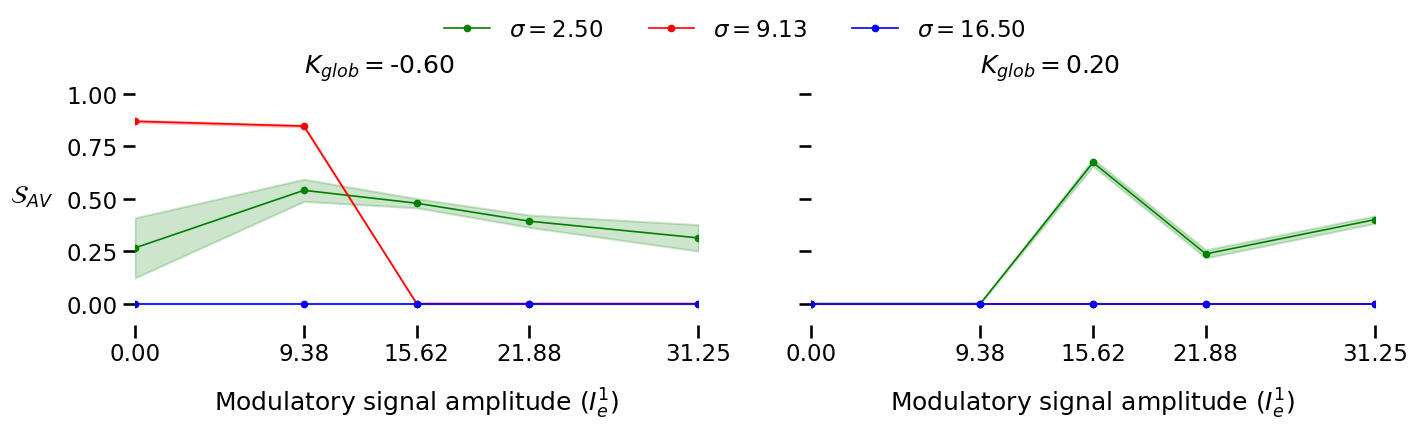

In [12]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{AV}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()


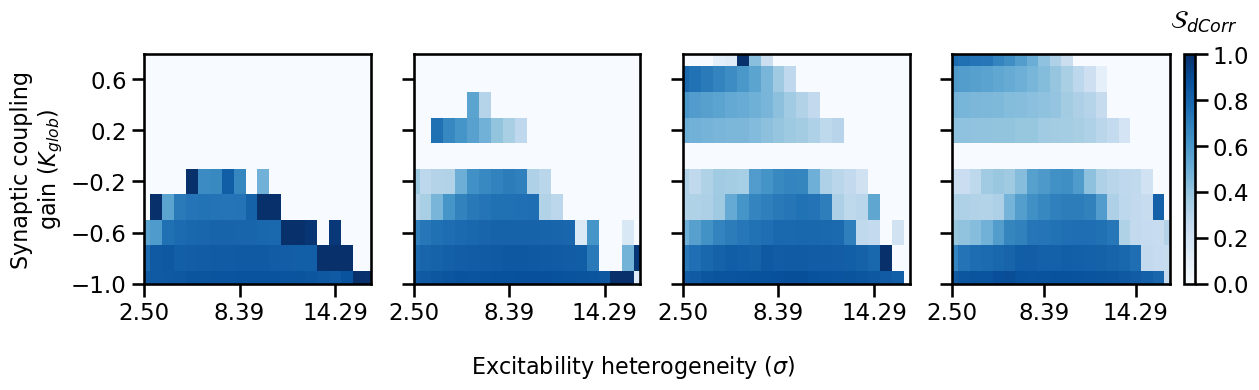

In [13]:
measure = "DistCor"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 

    dataArray[dataArray < 0.09] = 0

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{dCorr}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [14]:
measure = "DistCor"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-12/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_31.250mV.pkl


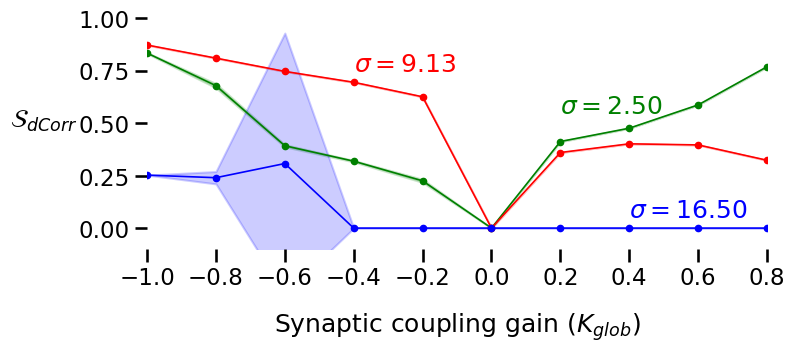

In [15]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{dCorr}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.2, 0.55, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(-0.4, 0.75, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(0.4, 0.05, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

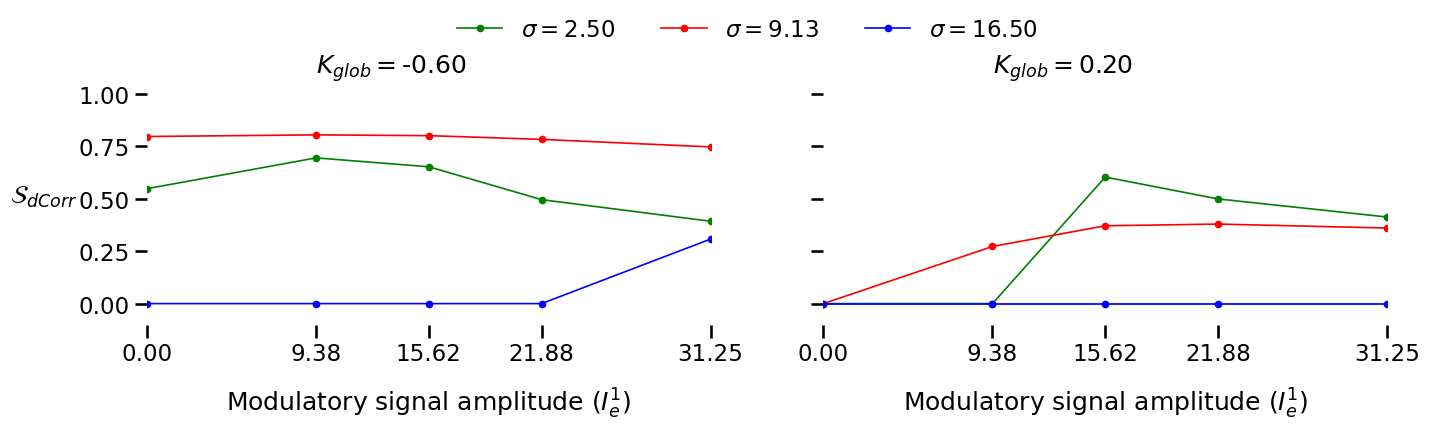

In [16]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
# axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
# axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
# axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
# axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
# axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{dCorr}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

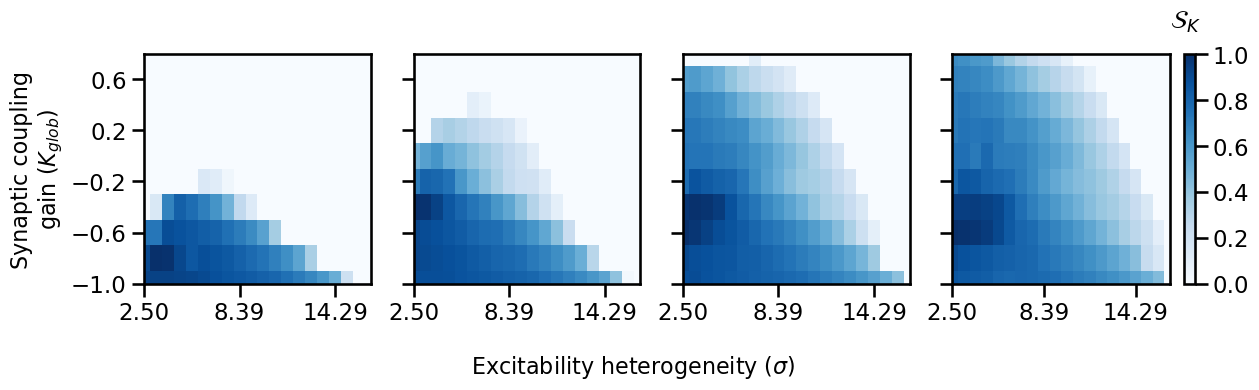

In [17]:
measure = "Kuramoto"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]

    dataArray = dataArray / np.max(dataArray)
    dataArray[np.isnan(dataArray)] = 0.0 

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{K}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [18]:
measure = "Kuramoto"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-12/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_31.250mV.pkl


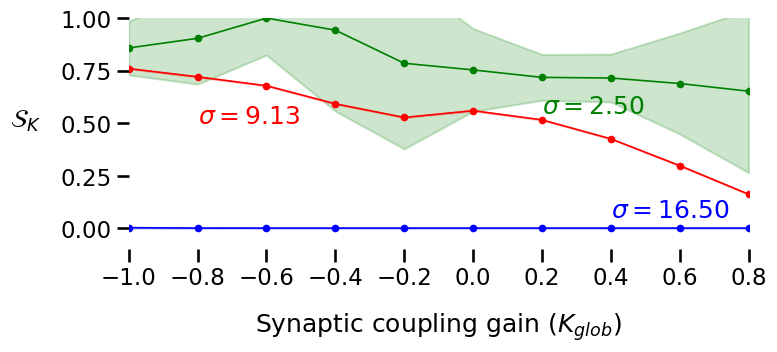

In [19]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{K}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.2, 0.55, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(-0.8, 0.5, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(0.4, 0.05, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

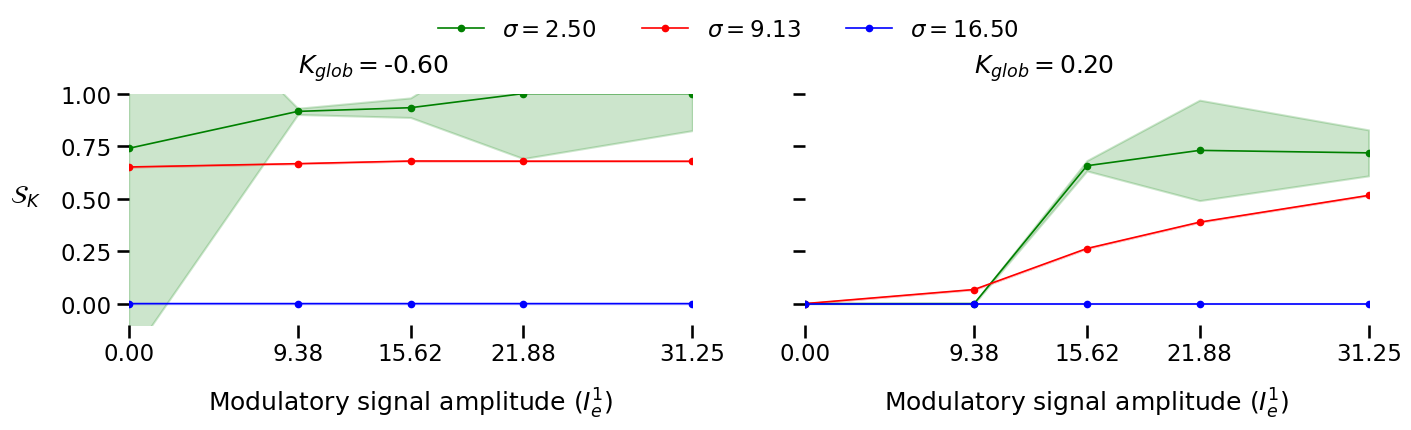

In [20]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{K}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

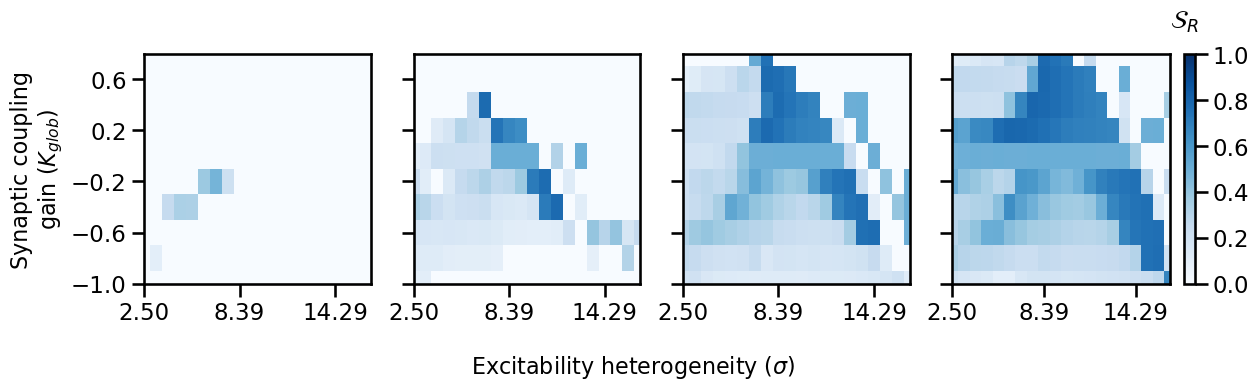

In [21]:
measure = "GlobalSync"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 

    dataArray[dataArray < 0.09] = 0

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{R}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [22]:
measure = "GlobalSync"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-12/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_31.250mV.pkl


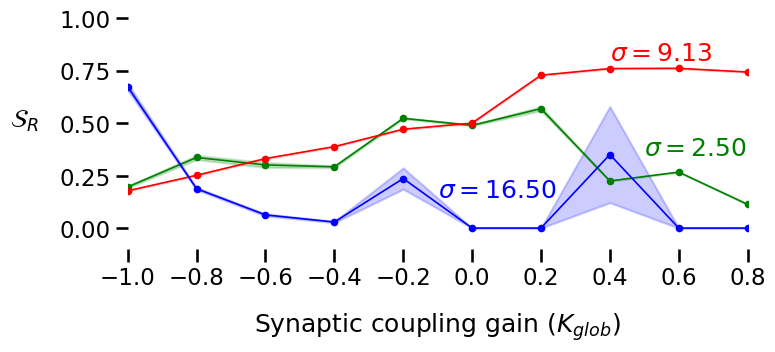

In [23]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{R}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.5, 0.35, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(0.4, 0.8, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(-0.1, 0.15, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

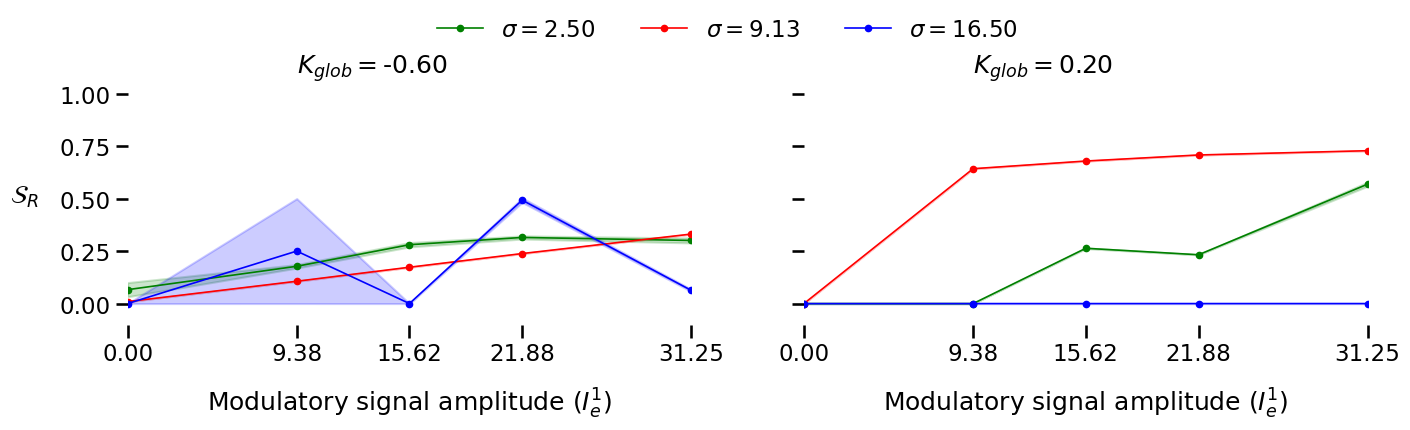

In [24]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{R}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

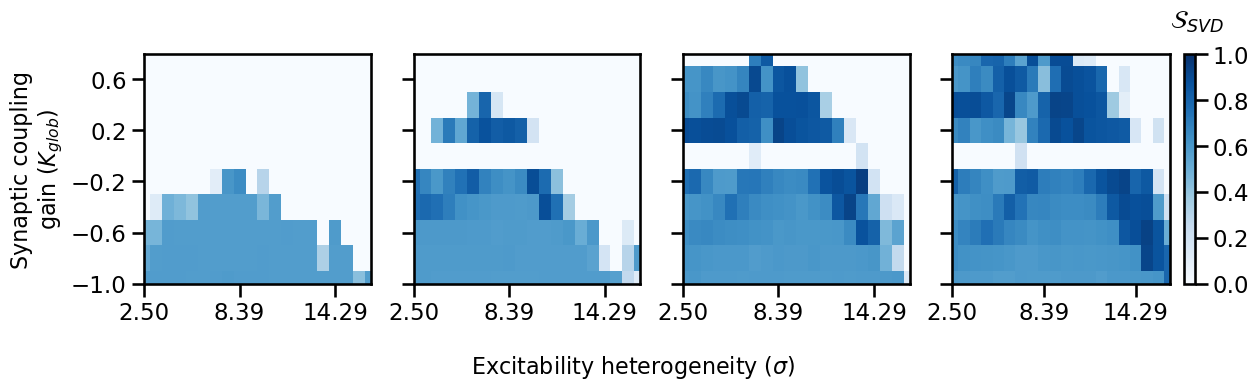

In [25]:
measure = "SVD"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 

    dataArray[dataArray < 0.09] = 0

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{SVD}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [26]:
measure = "SVD"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-12/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_31.250mV.pkl


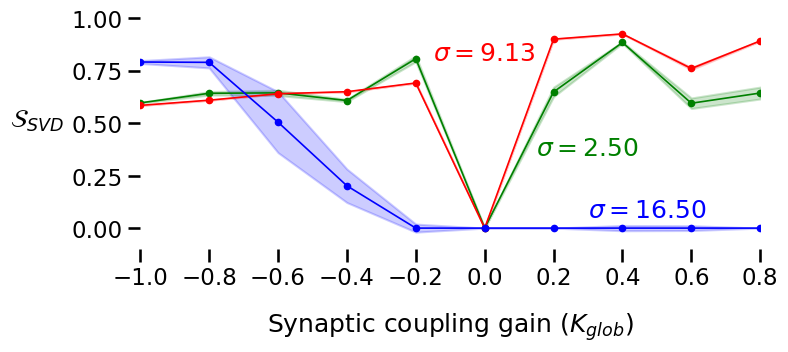

In [27]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{SVD}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.15, 0.35, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(-0.15, 0.8, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(0.3, 0.05, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

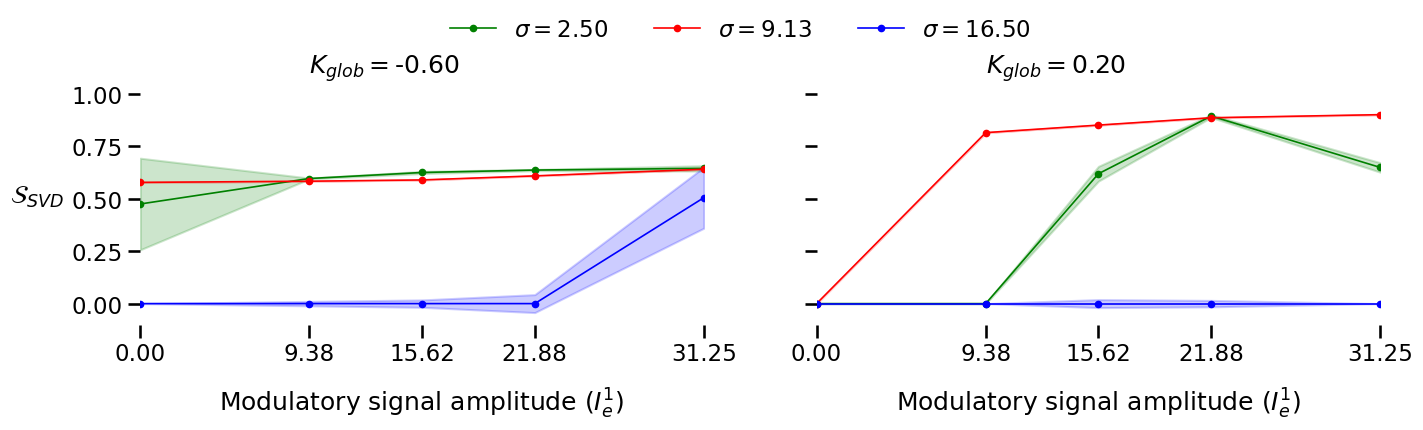

In [28]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{SVD}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

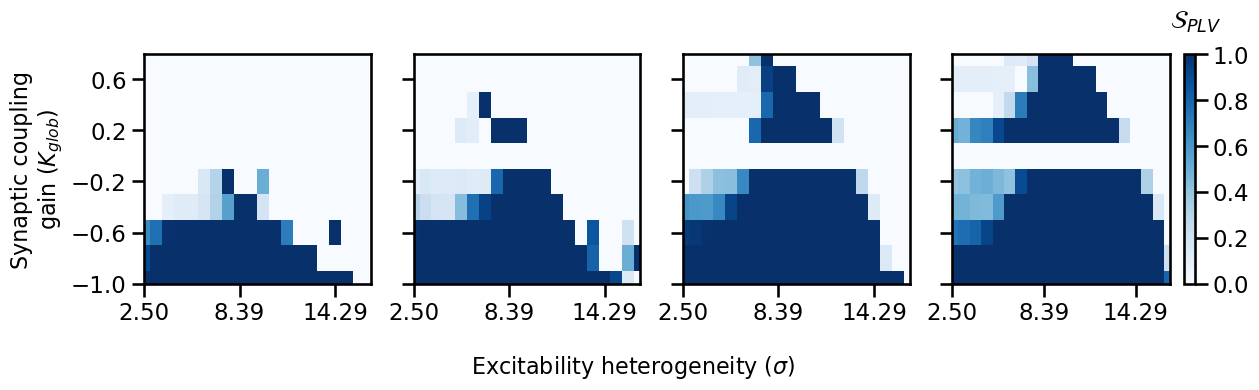

In [29]:
measure = "PLV"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 

    dataArray[dataArray < 0.09] = 0

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{PLV}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [30]:
measure = "PLV"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-12/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-12/Imod_31.250mV.pkl


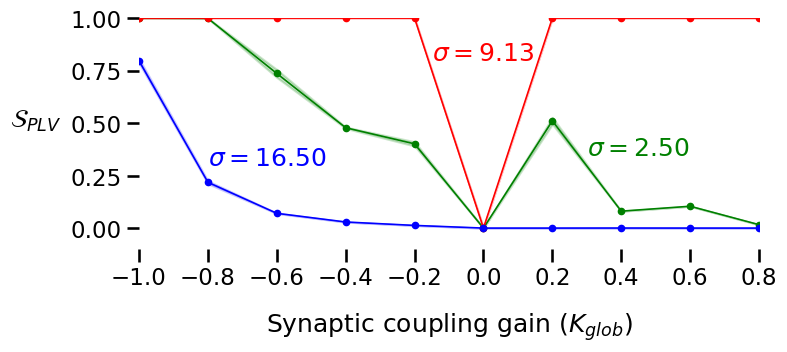

In [31]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{PLV}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.3, 0.35, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(-0.15, 0.8, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(-0.8, 0.3, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

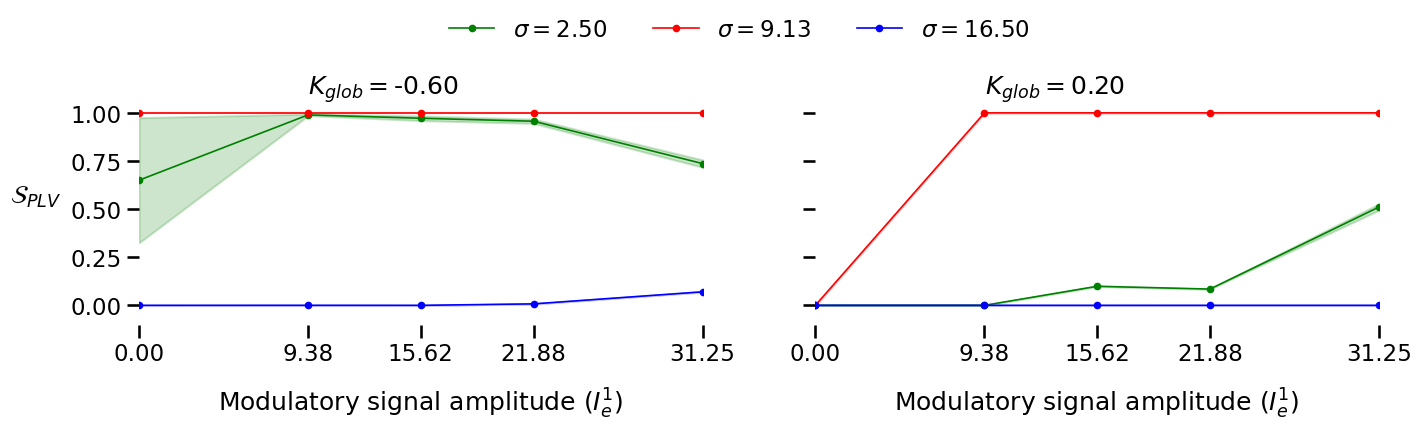

In [32]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{PLV}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1.1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

### Synchronization in LFOs

In [33]:
load_dir = "../system_01/results/synchron/"
load_str = datetime.datetime(2024, 4, 23)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, 'Imod*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 5


In [34]:
# Sorting the files

iVals = []

for path in file_paths:
    baseName = os.path.basename(path).split('mV.pkl')[0]
    I = float(baseName.split('_')[-1])

    iVals.append(I)

iVals = np.array(iVals)
iSort = np.argsort(iVals)

file_paths = np.array(file_paths)
file_paths = file_paths[iSort]
iVals = iVals[iSort]

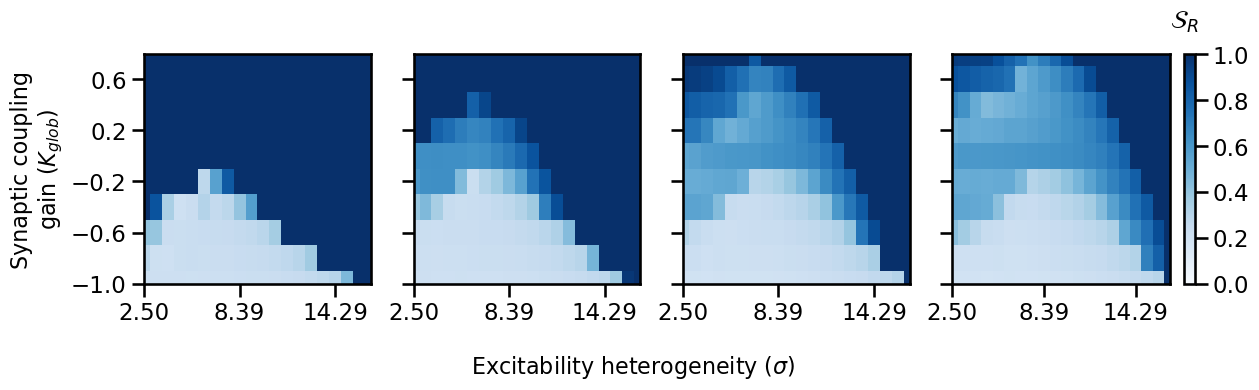

In [35]:
measure = "GlobalSync"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 

    dataArray[dataArray < 0.09] = 0

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{R}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_LFO_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [36]:
measure = "GlobalSync"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-23/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_31.250mV.pkl


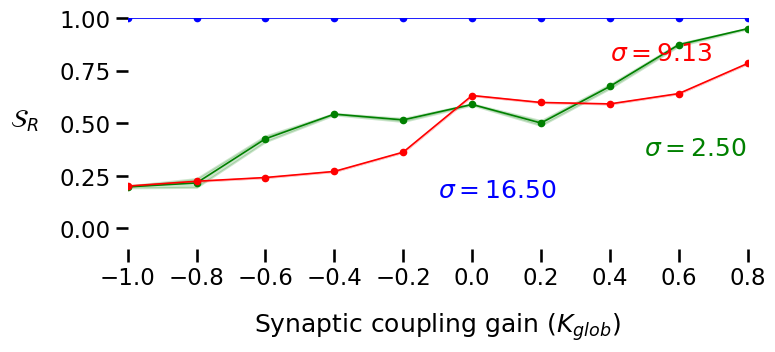

In [37]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{R}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.5, 0.35, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(0.4, 0.8, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(-0.1, 0.15, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_LFO_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

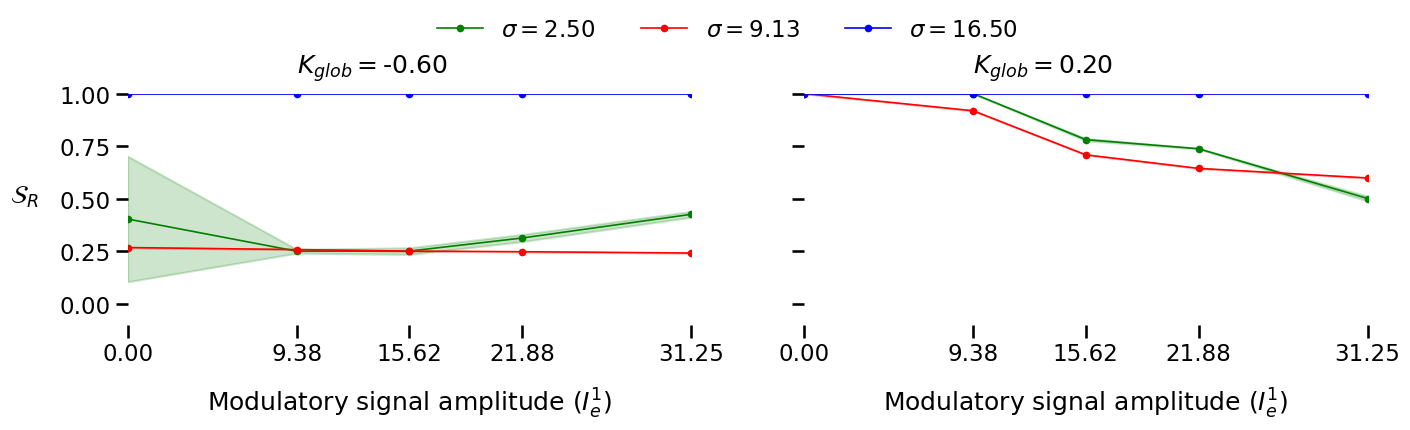

In [38]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{R}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_LFO_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

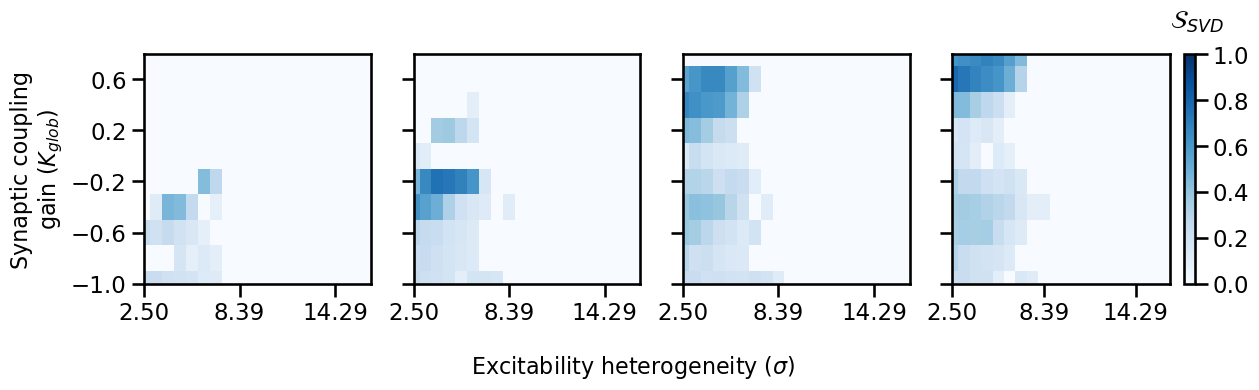

In [39]:
measure = "SVD"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 

    dataArray[dataArray < 0.09] = 0

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{SVD}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_LFO_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [40]:
measure = "SVD"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-23/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_31.250mV.pkl


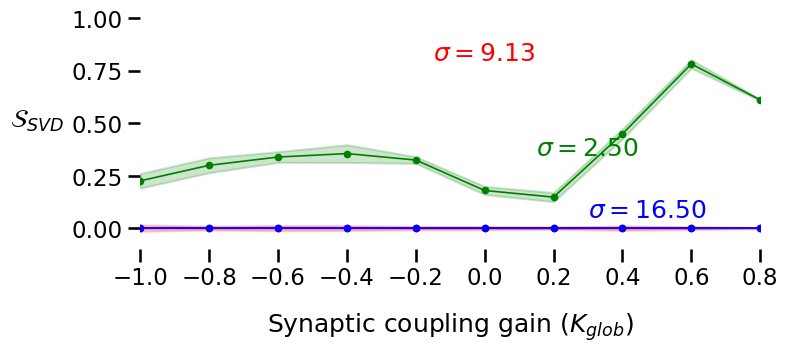

In [41]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{SVD}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.15, 0.35, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(-0.15, 0.8, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(0.3, 0.05, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_LFO_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

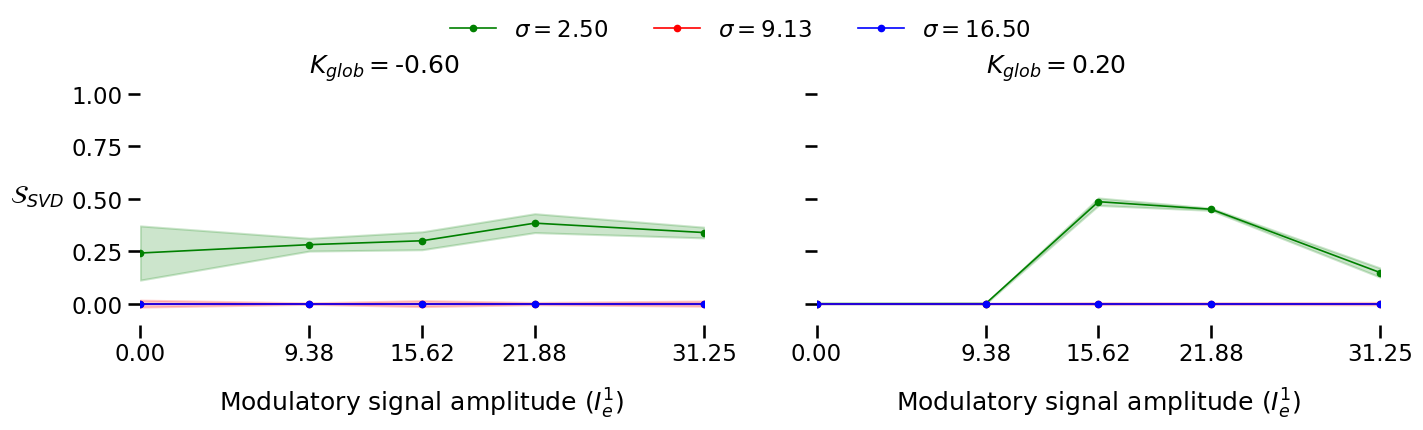

In [42]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{SVD}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_LFO_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

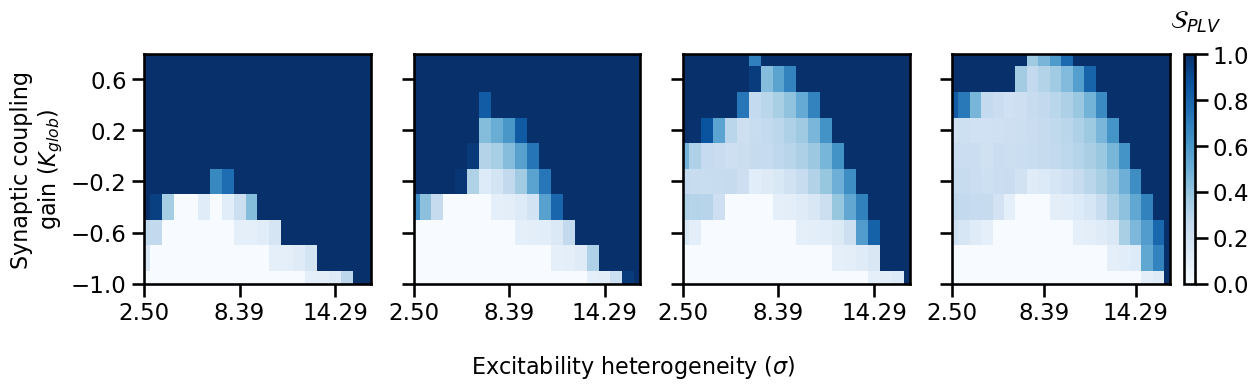

In [43]:
measure = "PLV"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 

    dataArray[dataArray < 0.09] = 0

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{PLV}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_LFO_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [44]:
measure = "PLV"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-23/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-23/Imod_31.250mV.pkl


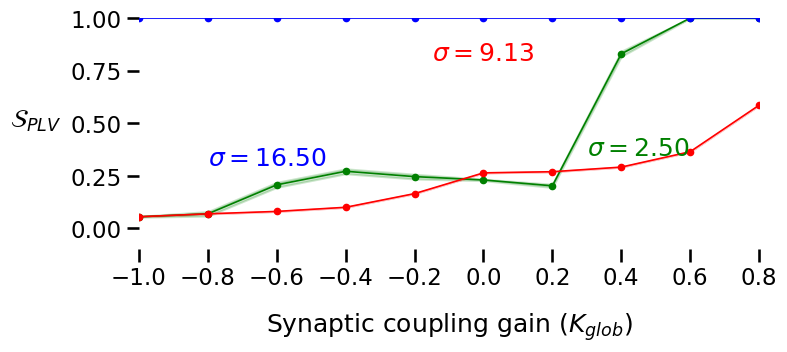

In [45]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{PLV}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.3, 0.35, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(-0.15, 0.8, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(-0.8, 0.3, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_LFO_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

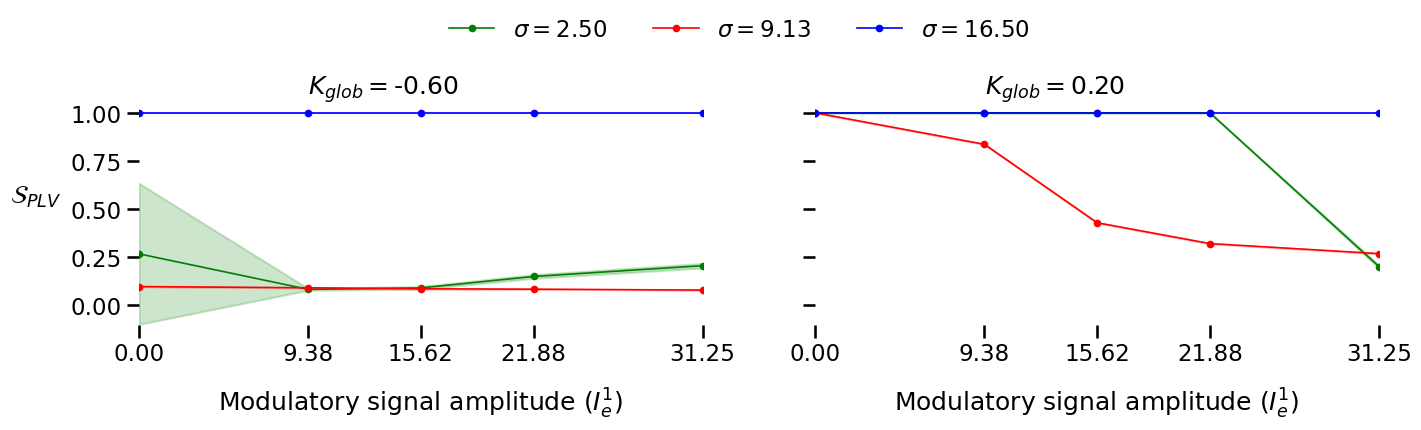

In [46]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{PLV}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1.1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_LFO_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

### Synchronization in HFOs

In [47]:
load_dir = "../system_01/results/synchron/"
load_str = datetime.datetime(2024, 4, 24)
sub_dir = f"exp-{load_str.year}-{load_str.month}-{load_str.day}"

results_dir = os.path.join(load_dir, sub_dir)
file_paths = glob.glob(os.path.join(results_dir, 'Imod*.pkl'))
print(f"Total no. of files = {len(file_paths)}")

Total no. of files = 5


In [48]:
# Sorting the files

iVals = []

for path in file_paths:
    baseName = os.path.basename(path).split('mV.pkl')[0]
    I = float(baseName.split('_')[-1])

    iVals.append(I)

iVals = np.array(iVals)
iSort = np.argsort(iVals)

file_paths = np.array(file_paths)
file_paths = file_paths[iSort]
iVals = iVals[iSort]

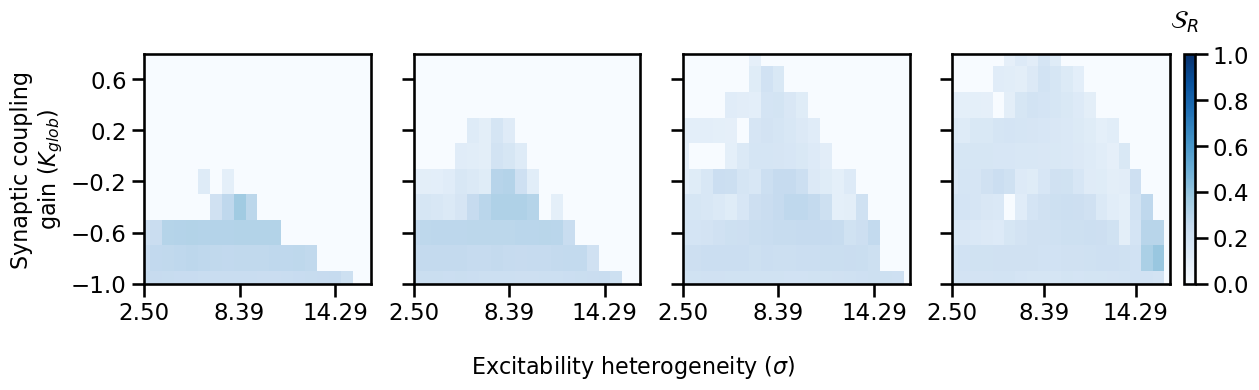

In [49]:
measure = "GlobalSync"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 

    dataArray[dataArray < 0.09] = 0

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{R}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_HFO_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [50]:
measure = "GlobalSync"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-24/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_31.250mV.pkl


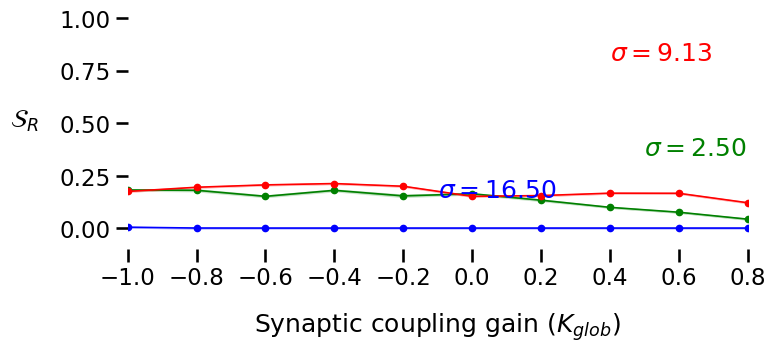

In [51]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{R}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.5, 0.35, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(0.4, 0.8, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(-0.1, 0.15, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_HFO_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

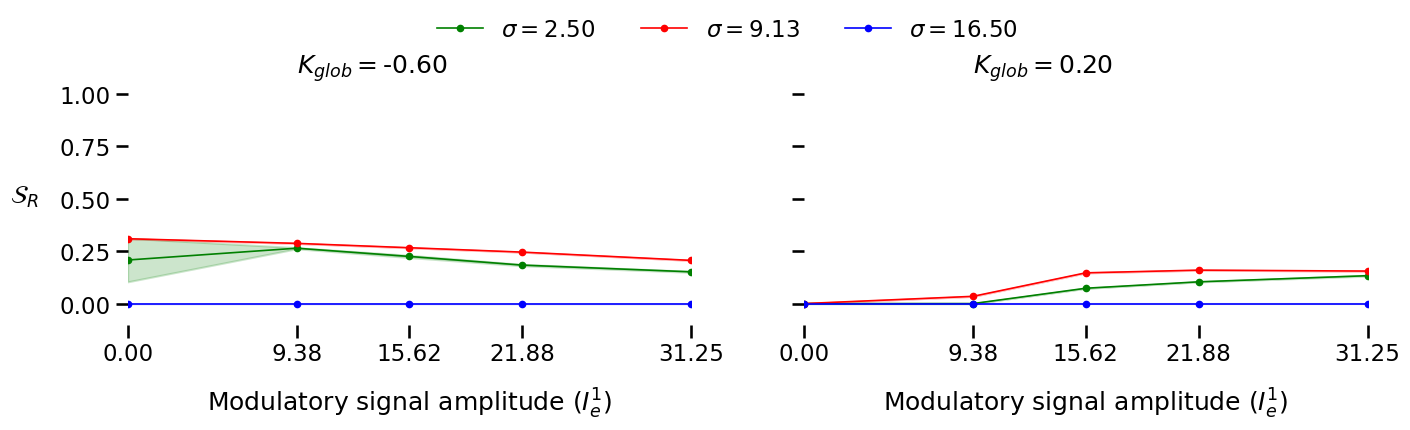

In [52]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{R}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_HFO_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

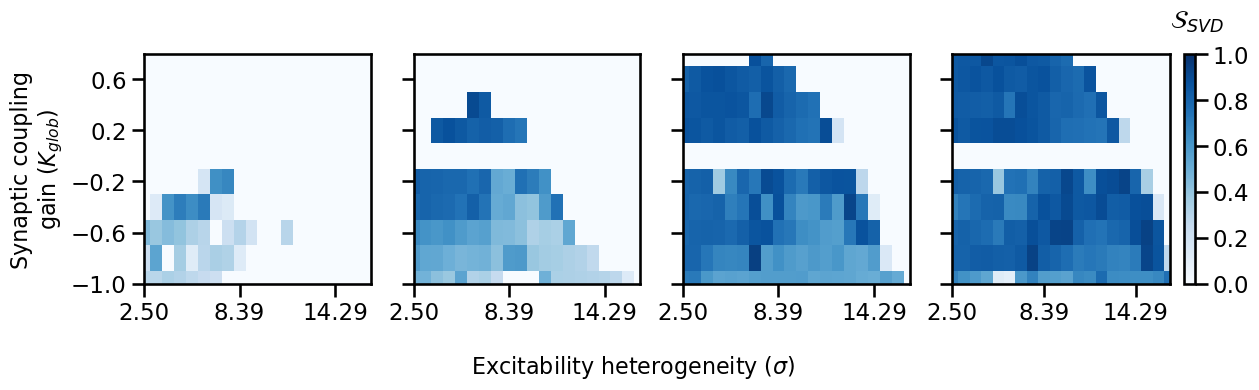

In [53]:
measure = "SVD"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 

    dataArray[dataArray < 0.09] = 0

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{SVD}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_HFO_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [54]:
measure = "SVD"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-24/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_31.250mV.pkl


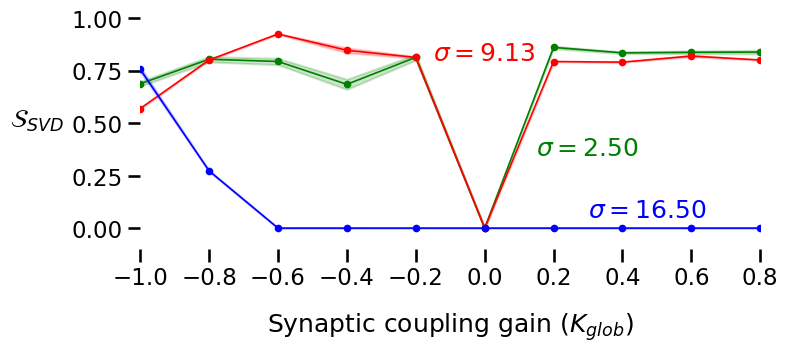

In [55]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{SVD}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.15, 0.35, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(-0.15, 0.8, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(0.3, 0.05, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_HFO_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

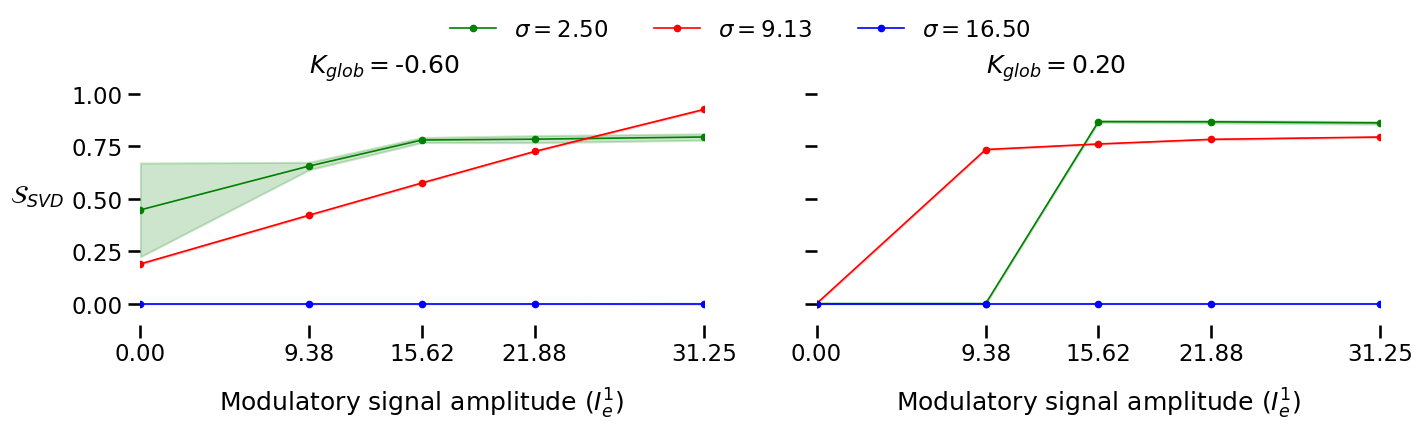

In [56]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{SVD}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_HFO_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

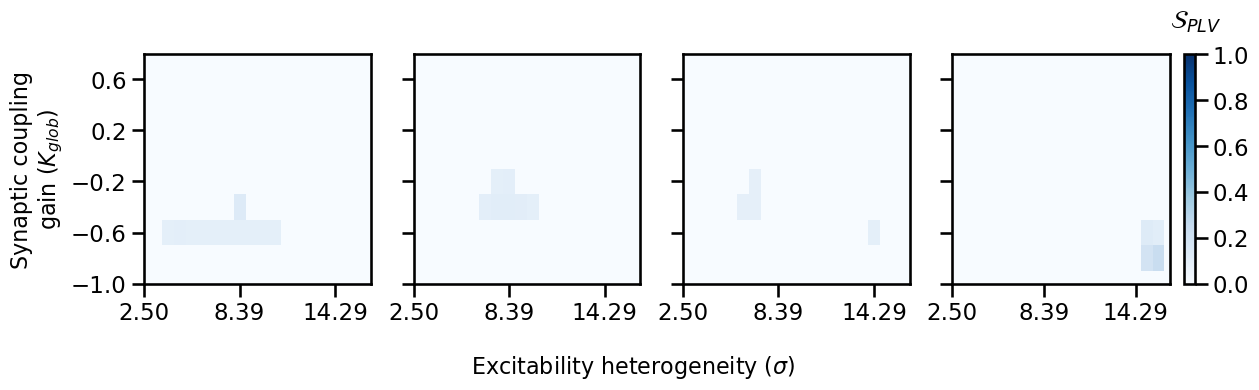

In [57]:
measure = "PLV"

fig, axes = plt.subplots(1, len(iPert) - 1, figsize=(12.8,4), sharey=True, gridspec_kw={'width_ratios':[1,1,1, 1.2]})
nRow, nCol = 0, 0

for nf, path in enumerate(file_paths):
    if nf == 2:
        continue
    baseName = os.path.basename(path).split('mV.pkl')[0]

    synchData = pickle.load(open(path, 'rb'))
    synchMean = synchData['Mean']

    dataArray = synchMean[measure]
    dataArray[np.isnan(dataArray)] = 0.0 

    dataArray[dataArray < 0.09] = 0

    pcor = axes[nCol].pcolormesh(eval_sigma, eval_k, dataArray, vmin=0, vmax=1, cmap='Blues')
    axes[nCol].set_ylim(min(eval_k), max(eval_k))
    axes[nCol].set_yticks(eval_k[::2])
    axes[nCol].set_xlim(sig_min, max(eval_sigma))
    axes[nCol].set_xticks(eval_sigma[::8])
    # axes[nCol].set_xlabel(f"Excitability\nHeterogeneity" + r"$(\sigma)$", fontsize=16)
    
    if nCol == 0:
        axes[nCol].set_ylabel(f"Synaptic coupling\ngain " + r"$(K_{glob})$", fontsize=16)
    nCol += 1
        
cbar = fig.colorbar(pcor, ax=axes[len(iPert) - 2])
axes[len(iPert) - 2].text(16.5, 1, r"$\mathcal{S}_{PLV}$", fontsize=18)
fig.supxlabel(f"Excitability heterogeneity " + r"$(\sigma)$", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(figureroot, f"{measure}_HFO_Responsemaps.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [58]:
measure = "PLV"

data_K_mean, data_K_std, data_I_mean, data_I_std = SeriesData(measure, file_paths)

../system_01/results/synchron/exp-2024-4-24/Imod_0.000mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_9.375mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_15.625mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_21.875mV.pkl
../system_01/results/synchron/exp-2024-4-24/Imod_31.250mV.pkl


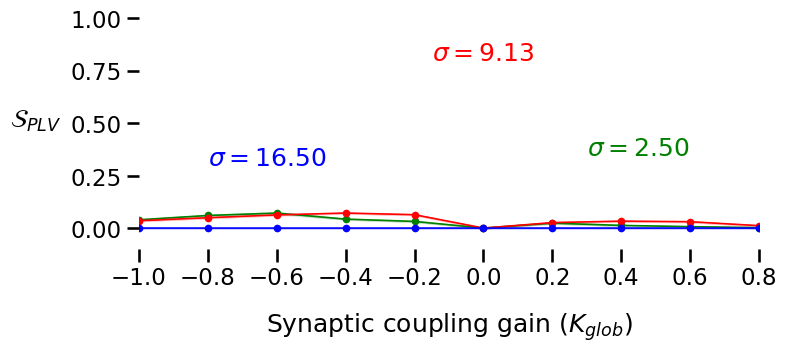

In [59]:
plt.figure(figsize=(8, 3))
plt.plot(eval_k, data_K_mean[0], 'g.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[0] - data_K_std[0], data_K_mean[0] + data_K_std[0], color='g', alpha=0.2)
plt.plot(eval_k, data_K_mean[1], 'r.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[1] - data_K_std[1], data_K_mean[1] + data_K_std[1], color='r', alpha=0.2)
plt.plot(eval_k, data_K_mean[2], 'b.-', linewidth=1.2)
plt.fill_between(eval_k, data_K_mean[2] - data_K_std[2], data_K_mean[2] + data_K_std[2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    plt.gca().spines[pos].set_visible(False)

plt.ylabel(r"$\mathcal{S}_{PLV}$", rotation=0, labelpad=25)
plt.xlim(k_min, max(eval_k))
plt.xticks(eval_k)
plt.ylim(-0.1, 1)
plt.xlabel(r"Synaptic coupling gain ($K_{glob}$)", labelpad=15)
plt.text(0.3, 0.35, r"$\sigma = $" + f"{eval_sigma[0]:.2f}", color='g', fontsize=18)
plt.text(-0.15, 0.8, r"$\sigma = $" + f"{eval_sigma[9]:.2f}", color='r', fontsize=18)
plt.text(-0.8, 0.3, r"$\sigma = $" + f"{eval_sigma[-1]:.2f}", color='b', fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_HFO_Imod_{iPert[-1]:.3f}mV_K.jpg"), dpi=300, bbox_inches='tight')
plt.show()

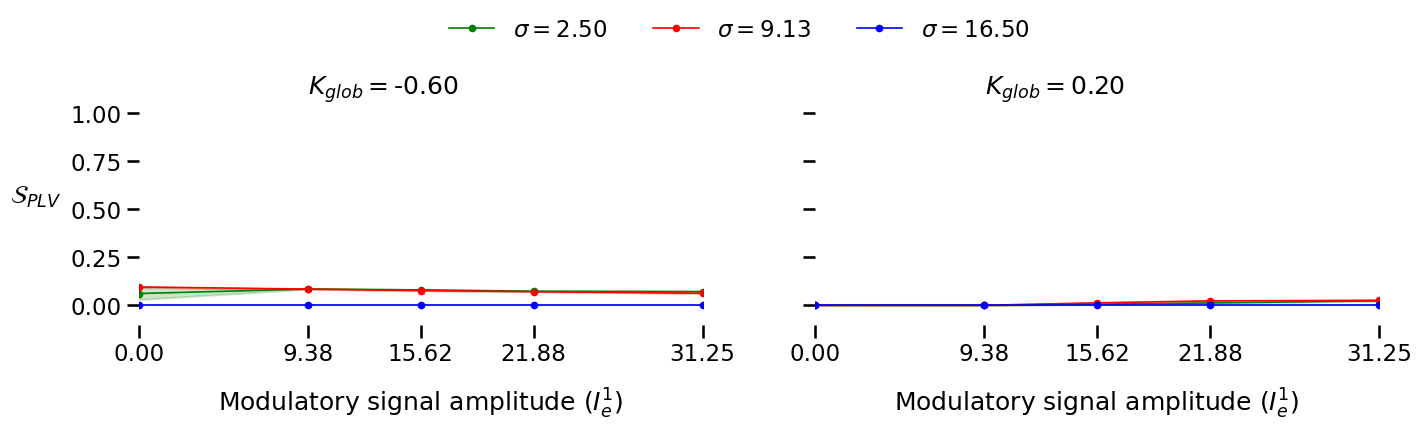

In [60]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(16, 3))
axes[0].plot(iPert, data_I_mean[0, 0], 'g.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 0] - data_I_std[0, 0], data_I_mean[0, 0] + data_I_std[0, 0], color='g', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 1], 'r.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 1] - data_I_std[0, 1], data_I_mean[0, 1] + data_I_std[0, 1], color='r', alpha=0.2)
axes[0].plot(iPert, data_I_mean[0, 2], 'b.-', linewidth=1.2)
axes[0].fill_between(iPert, data_I_mean[0, 2] - data_I_std[0, 2], data_I_mean[0, 2] + data_I_std[0, 2], color='b', alpha=0.2)

axes[1].plot(iPert, data_I_mean[1, 0], 'g.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[0]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 0] - data_I_std[1, 0], data_I_mean[1, 0] + data_I_std[1, 0], color='g', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 1], 'r.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[9]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 1] - data_I_std[1, 1], data_I_mean[1, 1] + data_I_std[1, 1], color='r', alpha=0.2)
axes[1].plot(iPert, data_I_mean[1, 2], 'b.-', linewidth=1.2, label=r"$\sigma = $" + f"{eval_sigma[-1]:.2f}")
axes[1].fill_between(iPert, data_I_mean[1, 2] - data_I_std[1, 2], data_I_mean[1, 2] + data_I_std[1, 2], color='b', alpha=0.2)

for pos in ["right", "left", "top", "bottom"]:
    axes[0].spines[pos].set_visible(False)
    axes[1].spines[pos].set_visible(False)

axes[0].set_ylabel(r"$\mathcal{S}_{PLV}$", rotation=0, labelpad=25)
axes[0].set_ylim(-0.1, 1.1)
for i in range(2):
    axes[i].set_xlim(min(iPert), max(iPert))
    axes[i].set_xticks(iPert)
    axes[i].set_xlabel(r"Modulatory signal amplitude ($I^1_e$)", labelpad=15)

fig.legend(loc='upper center', ncols=3, bbox_to_anchor=(0.5, 1.2), frameon=False)
axes[0].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[2]:.2f}", fontsize=18)
axes[1].text(9.38, 1.1, r"$K_{glob} = $" + f"{eval_k[6]:.2f}", fontsize=18)
plt.savefig(os.path.join(figureroot, f"{measure}_HFO_K_{eval_k[2]:.2f}_{eval_k[6]:.2f}Imod.jpg"), dpi=300, bbox_inches='tight')
plt.show()

In [17]:
# setting grid parameters
minval = -5 / params['gamma']
maxval = 5 / params['gamma']
grid_res = 100
n_trials = 10

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

# setting init values
np.random.seed(0)
x0_ = np.random.uniform(minval, maxval, n_trials)
x1_ = np.random.uniform(minval, maxval, n_trials)
x2_ = np.random.uniform(minval, maxval, n_trials)
x3_ = np.random.uniform(minval, maxval, n_trials)

t_start = 1000
t_end = params['T']

In [18]:
eval_sigma

array([ 2.5       ,  3.23684211,  3.97368421,  4.71052632,  5.44736842,
        6.18421053,  6.92105263,  7.65789474,  8.39473684,  9.13157895,
        9.86842105, 10.60526316, 11.34210526, 12.07894737, 12.81578947,
       13.55263158, 14.28947368, 15.02631579, 15.76315789, 16.5       ])

In [19]:
eval_k

array([-1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8])

In [32]:
params['i_e1'] = 0.5 / params['gamma'] + params['i_e2']
params['sig_e1'] = params['sig_e2'] = params['sig_i1'] = params['sig_i2'] = eval_sigma[9]
params['K'] = eval_k[2]

In [33]:
eval_k[6]

0.19999999999999996

In [34]:
u = np.zeros((n_trials, 4, T))
u = euler_intergrate(u, [x0_, x1_, x2_, x3_], **params)

ue1 = np.mean(u[:, 0, :], axis=0)
ue2 = np.mean(u[:, 2, :], axis=0)

In [35]:
center_freq=12.
fs=1000

freq_arr = np.linspace(1, fs / 2, 2000)
widths = center_freq * fs / (2 * freq_arr * np.pi)

wtmatr1 = signal.cwt(ue1[t_start:t_end] - np.mean(ue1[t_start:t_end]), signal.morlet2, widths, w=center_freq)
wtmatr2 = signal.cwt(ue2[t_start:t_end] - np.mean(ue2[t_start:t_end]), signal.morlet2, widths, w=center_freq)

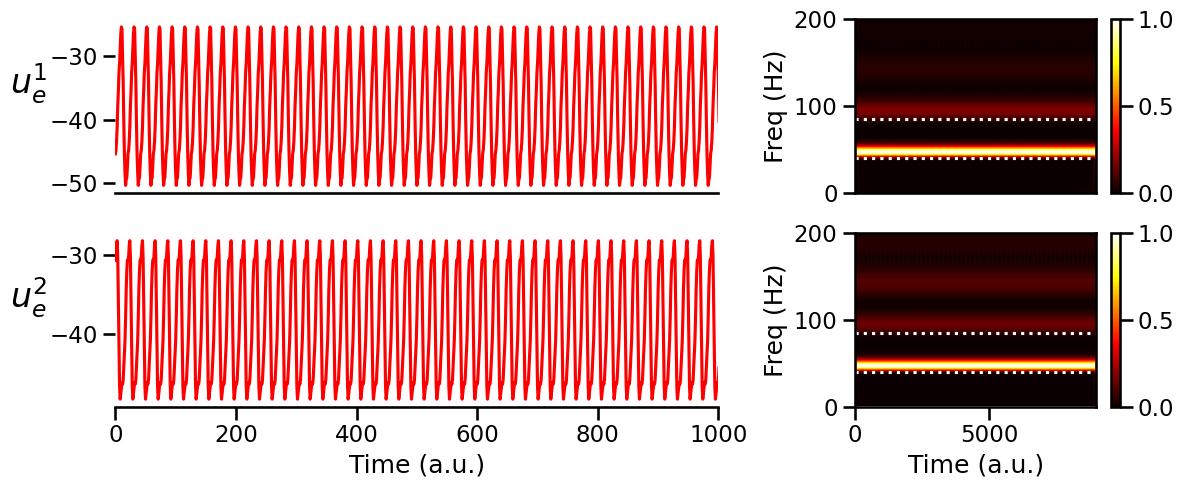

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 5), gridspec_kw={'width_ratios':[2,1]})
axes[0,0].plot(time_[:-t_start], ue1[t_start:], color='r')
axes[0,0].set_xlim(0, 1000)
axes[0,0].set_xticks([])
axes[0,0].set_ylabel(r"$u^1_e$", rotation=0, labelpad=15, fontsize=24)

pcs1 = axes[0,1].pcolormesh(time_[:-t_start], freq_arr, np.abs(wtmatr1) / np.max(np.abs(wtmatr1)+0.0001), cmap='hot', vmin=0, vmax=1)
cbar1 = fig.colorbar(pcs1, ax=axes[0,1], location='right', pad=0.05)
axes[0,1].axhline(y=40, color='w', linestyle=":")
axes[0,1].axhline(y=85, color='w', linestyle=":")
axes[0,1].set_ylim(0, 200)
axes[0,1].set_xticks([])
axes[0,1].set_ylabel("Freq (Hz)")


axes[1,0].plot(time_[:-t_start], ue2[t_start:], color='r')
axes[1,0].set_xlim(0, 1000)
axes[1,0].set_ylabel(r"$u^2_e$", rotation=0, labelpad=15, fontsize=24)
axes[1,0].set_xlabel("Time (a.u.)")

pcos2 = axes[1,1].pcolormesh(time_[:-t_start], freq_arr, np.abs(wtmatr2) / np.max(np.abs(wtmatr2)+0.0001), cmap='hot', vmin=0, vmax=1)
cbar2 = fig.colorbar(pcos2, ax=axes[1,1], location='right', pad=0.05)
axes[1,1].axhline(y=40, color='w', linestyle=":")
axes[1,1].axhline(y=85, color='w', linestyle=":")
axes[1,1].set_ylim(0, 200)
axes[1,1].set_xlabel("Time (a.u.)")
axes[1,1].set_ylabel("Freq (Hz)")

for pos in ["right", "left", "top"]:
    axes[0, 0].spines[pos].set_visible(False)
    axes[1, 0].spines[pos].set_visible(False)

plt.tight_layout()
plt.show()

In [37]:
# comments - 
# (1) Remove these measures - nCor, MI on amplitudes and phase (Mention the use of this but the patterns were random and no informatation on the relationship between the MI and heterogeneity could be taken), Temporal intersection
# (2) Keep these measures - Avalanche Synchronization (Time series), Kuramoto (Time series), , dCorrelation (Time series), 
#                           Global Synchronization (Spectral), SVD-based Measure (Spectral), PVL (Spectral)
